In [1]:
import pandas as pd

# Load your CSV file (replace with your filename)
df= pd.read_csv("gpt-4o_eval_with_bert_REFERENCE - full.csv")
# df.head(10)

In [2]:
df_full = df[df['question type'] != 'Reasoning Questions']
df_full = df_full[df_full['Evaluation'].isin(['0', '1'])]

df_full.Evaluation.info


<bound method Series.info of 0     1
1     1
2     1
3     1
4     1
     ..
70    1
71    1
72    1
73    1
74    1
Name: Evaluation, Length: 68, dtype: object>

In [3]:
from collections import Counter
import difflib

def lcs_ratio(a, b):
    return difflib.SequenceMatcher(None, a.lower(), b.lower()).ratio()

def token_f1(reference, prediction):
    ref_tokens = reference.lower().split()
    pred_tokens = prediction.lower().split()

    ref_counts = Counter(ref_tokens)
    pred_counts = Counter(pred_tokens)

    overlap = sum((ref_counts & pred_counts).values())

    precision = overlap / len(pred_tokens) if pred_tokens else 0
    recall = overlap / len(ref_tokens) if ref_tokens else 0

    if precision + recall == 0:
        return 0
    return 2 * precision * recall / (precision + recall)

def jaccard_similarity(a, b):
    a_set = set(a.lower().split())
    b_set = set(b.lower().split())
    intersection = a_set & b_set
    union = a_set | b_set
    return len(intersection) / len(union) if union else 0


In [4]:
df_full["lcs_score"] = df_full.apply(lambda row: lcs_ratio(str(row["Expected Answer"]), str(row["Model Answer"])), axis=1)
df_full["token_f1"] = df_full.apply(lambda row: token_f1(str(row["Expected Answer"]), str(row["Model Answer"])), axis=1)
df_full["jaccard"] = df_full.apply(lambda row: jaccard_similarity(str(row["Expected Answer"]), str(row["Model Answer"])), axis=1)


In [5]:
df_full["reasoning_score"] = (
    0.5 * df_full["token_f1"] +
    0.3 * df_full["jaccard"] +
    0.2 * df_full
    ["lcs_score"]
)


        token_f1    jaccard  lcs_score  reasoning_score
count  68.000000  68.000000  68.000000        68.000000
mean    0.141515   0.101263   0.179357         0.137008
std     0.181026   0.142571   0.229350         0.173644
min     0.000000   0.000000   0.000000         0.000597
25%     0.027044   0.022450   0.014062         0.026772
50%     0.078704   0.055424   0.062713         0.074330
75%     0.180556   0.118459   0.281815         0.174211
max     0.800000   0.666667   0.814815         0.762963


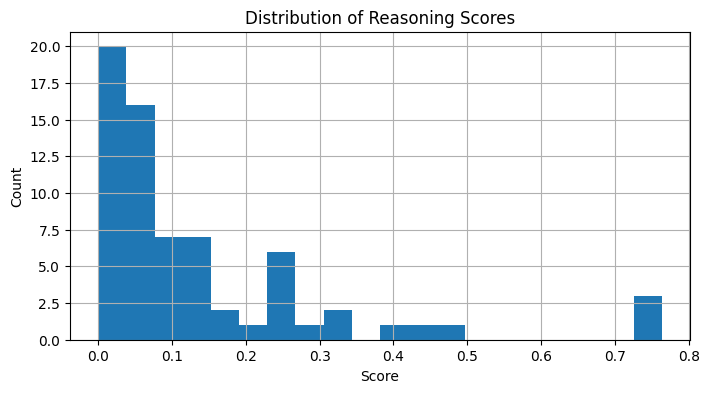

In [6]:
# Basic statistics
print(df_full[["token_f1", "jaccard", "lcs_score", "reasoning_score"]].describe())

# Histogram to see score distribution
import matplotlib.pyplot as plt

df_full["reasoning_score"].hist(bins=20, figsize=(8,4))
plt.title("Distribution of Reasoning Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()
